## **Resumen Ejecutivo: Infinitrack Earth Slicer**

Es una arquitectura de ingeniería de datos diseñada para la recuperación y normalización de prensa histórica a gran escala.

### **1. Filosofía de Diseño: El Modelo Modular**

El sistema opera mediante cuatro fases independientes, lo que permite mitigar bloqueos y adaptar la extracción a la arquitectura específica de cada medio de comunicación.

#### **Fase 1: TRENCHER (Excavación de Fuentes)**

Identifica el inventario de noticias para la fecha objetivo. Clasifica los medios en:

- **Fuentes Activas:** Localización de archivos mediante mapas XML (_Sitemaps_).
- **Fuentes Arqueológicas:** Reconstrucción del inventario mediante la **Wayback Machine** para medios con historiales borrados o protegidos.

#### **Fase 2: TUNNELLER (Cosecha y Validación de Enlaces)**

Extrae y depura las URLs específicas de las noticias:

- **Limpieza Técnica:** Transforma enlaces de visualización limitada (_embeds_) en accesos a notas completas.
- **Filtrado de Calidad:** Elimina automáticamente contenido irrelevante (horóscopos, recetas, avisos judiciales) para asegurar un dataset estrictamente periodístico.

#### **Fase 3: HARVESTER (Minería de Contenido de Alta Resiliencia)**

Motor de extracción profunda con una tasa de éxito superior al 95%:

- **Aislamiento de Sesión:** Procesa cada link en una cápsula de memoria limpia para evadir firewalls.
- **Identidad Selectiva:** Alterna entre perfiles de usuario humano y rastreador oficial (_Googlebot_) según la seguridad del sitio.
- **Extracción Multicapa:** Prioriza metadatos ocultos (JSON-LD) y activa una **Heurística de Párrafos** si el diseño visual del sitio ha cambiado o está dañado.

#### **Fase 4: EARTH SLICER CLEANER (Refinamiento y Normalización)**

Transforma el texto bruto en un producto estructurado listo para el análisis:

- **Reparación Lingüística:** Corrige errores de codificación y caracteres deformados.
- **Diccionario de Ruido Dinámico:** Detecta y elimina automáticamente menús, pies de página y bloques publicitarios repetitivos.
- **Deduplicación Semántica:** Identifica noticias repetidas mediante algoritmos matemáticos y unifica categorías (ej: agrupa "Negocios" y "Finanzas" en "Economía").

---

### **2. Valor Agregado y Resultados**

- **Precisión Histórica:** Validación de fechas mediante una **Jerarquía de Confianza** que cruza metadatos y rastros digitales.
- **Dataset Optimizado:** Entrega un archivo final normalizado, libre de ruido y duplicados, diseñado específicamente para **Machine Learning, Análisis de Sentimiento y Mapeo de Actores.**

De esta forma se garantiza la obtención de evidencia documental histórica verificable, procesable y de alta fidelidad.


In [3]:
import pandas as pd
from datetime import datetime, timedelta

# Fecha de inicio y fecha de fin de la recoleección
fecha_inicio = datetime(2025, 3, 14)
fecha_fin = datetime(2025, 4, 25)

# Crear un dataframe vacio
df_total = pd.DataFrame()

# Bucle principal
current_date = fecha_inicio
while current_date <= fecha_fin:
    date_str = current_date.strftime('%Y-%m-%d')
    filename = f'dataset_ecuador_{date_str}.csv'
    try:
        df_temp = pd.read_csv(filename)
        df_total = pd.concat([df_total, df_temp], ignore_index=True)
    except FileNotFoundError:
        print(f"File {filename} not found.")
    current_date += timedelta(days=1)

# Resultado
display(df_total)

,medio,fecha,seccion,titular,cuerpo,url
0,Primicias,14-03-2025,General,Así han conquistado las mujeres su espacio en ...,"Fue hace casi siete años, en 2018 . Y era, cas...",https://www.primicias.ec/deportes/asi-han-conq...
1,La Hora,14-03-2025,General,Elecciones Ecuador 2025: ¿las prioridades de l...,País Elecciones Ecuador 2025: ¿las prioridades...,https://www.lahora.com.ec/pais/conaie-priorida...
2,La Hora,14-03-2025,General,Campo Sacha: más ingresos y menos riesgos para...,País Campo Sacha: más ingresos y menos riesgos...,https://www.lahora.com.ec/pais/mas-ingresos-me...
3,La Hora,14-03-2025,General,¿Es posible atraer $8.400 millones de inversió...,País ¿Es posible atraer $8.400 millones de inv...,https://www.lahora.com.ec/pais/es-posible-atra...
4,Teleamazonas,14-03-2025,General,"Diego González, un cirujano ambulante en un qu...",Diego González Rivas acaba de llegar a su tier...,https://www.teleamazonas.com/diego-gonzalez-ci...
...,...,...,...,...,...,...
10749,El Universo,25-04-2025,Sucesos/Seguridad,"Dejan cabeza humana, parte de órgano y mensaje...",Un mensaje escrito con letras de color rojo en...,https://www.eluniverso.com/noticias/seguridad/...
10750,El Universo,25-04-2025,Política,Los seis asambleístas electos por la provincia...,Este viernes 25 de abril se realizó en Cuenca ...,https://www.eluniverso.com/noticias/politica/l...
10751,El Universo,25-04-2025,Economía,Operaciones de la Refinería de Esmeraldas y de...,Por el sismo de magnitud 6 ocurrido la mañana ...,https://www.eluniverso.com/noticias/economia/s...
10752,Metro Ecuador,25-04-2025,General,Sismo de 6.0 se siente en Esmeraldas y varias ...,Este 25 de abril a las 06:44 se sintió un temb...,https://www.metroecuador.com.ec/noticias/2025/...


In [4]:
# Configurar pandas para ver textos completos y todas las columnas
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [5]:
print("=" * 60)
print("📋 COLUMNAS DEL DATASET")
print("=" * 60)
for i, col in enumerate(df_total.columns, 1):
    print(f"   {i:02d}. {col}")

📋 COLUMNAS DEL DATASET
   01. medio
   02. fecha
   03. seccion
   04. titular
   05. cuerpo
   06. url


In [6]:
print("=" * 60)
print("📏 DIMENSIONES")
print("=" * 60)
print(f"   Número de filas (registros): {df_total.shape[0]:,}")
print(f"   Número de columnas (campos):  {df_total.shape[1]}")

📏 DIMENSIONES
   Número de filas (registros): 10,754
   Número de columnas (campos):  6


In [7]:
print("=" * 60)
print("🧬 TIPOS DE DATOS Y USO DE MEMORIA")
print("=" * 60)
# verbose=True muestra tipos detallados y memoria estimada
df_total.info(verbose=True, memory_usage='deep')

🧬 TIPOS DE DATOS Y USO DE MEMORIA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10754 entries, 0 to 10753
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   medio    10754 non-null  object
 1   fecha    10754 non-null  object
 2   seccion  10754 non-null  object
 3   titular  8930 non-null   object
 4   cuerpo   10754 non-null  object
 5   url      10754 non-null  object
dtypes: object(6)
memory usage: 62.4 MB


In [8]:
print("=" * 60)
print("🚫 VALORES FALTANTES (NULOS/VACÍOS)")
print("=" * 60)

# Cálculo vectorizado de nulos y porcentajes
faltantes = df_total.isnull().sum()
faltantes_pct = (faltantes / len(df_total)) * 100

reporte_nulos = pd.DataFrame({
    'Columna': faltantes.index,
    'Nulos': faltantes.values,
    'Porcentaje': faltantes_pct.values
}).sort_values('Nulos', ascending=False)

# Solo columnas con al menos un nulo
reporte_filtrado = reporte_nulos[reporte_nulos['Nulos'] > 0]

if len(reporte_filtrado) == 0:
    print("   ✅ No se encontraron valores nulos en ninguna columna.")
else:
    for _, fila in reporte_filtrado.iterrows():
        print(f"   - {fila['Columna']:30s}: {fila['Nulos']:6d} nulos ({fila['Porcentaje']:5.1f}%)")
    
total_nulos = faltantes.sum()
total_celdas = df_total.size
print(f"\n   📌 Total de celdas vacías: {total_nulos:,} de {total_celdas:,} "
      f"({100*total_nulos/total_celdas:.2f}%)")

🚫 VALORES FALTANTES (NULOS/VACÍOS)
   - titular                       :   1824 nulos ( 17.0%)

   📌 Total de celdas vacías: 1,824 de 64,524 (2.83%)


In [9]:
print("=" * 60)
print("📊 ESTADÍSTICAS BÁSICAS DE COLUMNAS DE TEXTO")
print("=" * 60)

columnas_texto = df_total.select_dtypes(include=['object']).columns.tolist()

for col in columnas_texto:
    n_unicos = df_total[col].nunique()
    print(f"\n   Columna '{col}':")
    print(f"      - Valores únicos: {n_unicos}")
    
    longitudes = df_total[col].dropna().astype(str).str.len()
    if len(longitudes) > 0:
        print(f"      - Longitud promedio de caracteres: {longitudes.mean():.0f}")
        print(f"      - Longitud mediana: {longitudes.median():.0f}")
        print(f"      - Longitud mínima / máxima: {longitudes.min()} / {longitudes.max()}")
    else:
        print("      - (columna completamente vacía)")

📊 ESTADÍSTICAS BÁSICAS DE COLUMNAS DE TEXTO

   Columna 'medio':
      - Valores únicos: 8
      - Longitud promedio de caracteres: 10
      - Longitud mediana: 9
      - Longitud mínima / máxima: 7 / 15

   Columna 'fecha':
      - Valores únicos: 43
      - Longitud promedio de caracteres: 10
      - Longitud mediana: 10
      - Longitud mínima / máxima: 10 / 10

   Columna 'seccion':
      - Valores únicos: 6
      - Longitud promedio de caracteres: 8
      - Longitud mediana: 7
      - Longitud mínima / máxima: 7 / 17

   Columna 'titular':
      - Valores únicos: 8825
      - Longitud promedio de caracteres: 85
      - Longitud mediana: 84
      - Longitud mínima / máxima: 17 / 183

   Columna 'cuerpo':
      - Valores únicos: 10693
      - Longitud promedio de caracteres: 2851
      - Longitud mediana: 2390
      - Longitud mínima / máxima: 201 / 29341

   Columna 'url':
      - Valores únicos: 10603
      - Longitud promedio de caracteres: 108
      - Longitud mediana: 105
     

### **EJERCICIO DE ANÁLISIS AUTOMATIZADO DEL DISCURSO**

_Caso: Derrame petrolero en Esmeraldas, Ecuador. Marzo-abril de 2025_

**Resumen Ejecutivo de la Metodología**

Se propone una metodología computacional de vanguardia para analizar, con profundidad y a gran escala, el discurso de alrededor de 5.000 noticias de 40 medios de comunicación sobre el derrame de petróleo en Esmeraldas (Ecuador, 2025). Combinamos técnicas avanzadas de Procesamiento de Lenguaje Natural (PLN) e Inteligencia Artificial con una sólida validación humana, garantizando resultados rigurosos, interpretables y accionables.

El análisis se estructura en tres capas interconectadas:

1. **Detección automática de temas y actores**: Identificamos, sin intervención manual, todos los grandes temas que aparecen en la cobertura (impacto ambiental, respuesta gubernamental, crisis económica, salud pública, etc.), así como los actores mencionados (Petroecuador, comunidades, ONG, políticos) y cómo se relacionan entre sí.
2. **Medición del enfoque y la emoción**: Aplicamos modelos de lenguaje que “leen” el texto para clasificar cómo se enmarca la noticia (¿se presenta como accidente, como crimen, como catástrofe natural?), qué sentimiento expresa hacia cada entidad (ira, esperanza, indignación) y cuáles son los argumentos morales o ideológicos subyacentes.
3. **Evolución temporal y comparación entre medios**: Detectamos cómo cambian las narrativas día a día, qué voces ganan o pierden protagonismo, y si existen diferencias sistemáticas entre medios locales/nacionales o entre secciones (política, economía, ambiente).

El resultado es un **mapa integral del discurso mediático**. Esta herramienta permite a universidades, organismos de gestión de crisis y medios de comunicación comprender cómo se construyó la historia del derrame, identificar sesgos o vacíos informativos, y elaborar estrategias de comunicación pública más efectivas y responsables en escenarios de crisis socioambiental.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
# Asegurar que la columna de fecha es datetime y crear copia de trabajo
df_total['fecha'] = pd.to_datetime(df_total['fecha'], errors='coerce')

# Estilo profesional para revistas (fuente, tamaño, sin grid excesivo)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})
sns.set_style("whitegrid")

def tabla_frecuencia(serie, nombre_categoria, orden=None):
    conteo = serie.value_counts()
    if orden is not None:
        # Si se pasa un orden (por ejemplo, fechas únicas ordenadas)
        conteo = conteo.reindex(orden, fill_value=0)
    total = conteo.sum()
    df = pd.DataFrame({
        nombre_categoria: conteo.index,
        'N.º de noticias': conteo.values,
        'Porcentaje (%)': (conteo.values / total * 100).round(2)
    })
    df['Porcentaje (%)'] = df['Porcentaje (%)'].map('{:.2f}%'.format)
    return df, total

# Todas las fechas únicas en rango completo, incluso si no hubo noticias ese día
rango_fechas = pd.date_range(start=df_total['fecha'].min(), end=df_total['fecha'].max(), freq='D')
tabla_fecha, total_fecha = tabla_frecuencia(df_total['fecha'].dt.date, 'Fecha', orden=rango_fechas.date)

print(f"📅 Distribución por fecha (total de noticias: {total_fecha})")
display(tabla_fecha.style
    .set_caption("Tabla 1. Frecuencia de noticias por día")
    .bar(subset=['N.º de noticias'], color="#120447", vmin=0)
    .format({'N.º de noticias': '{:,.0f}'})
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index')
)

📅 Distribución por fecha (total de noticias: 10754)


C:\Users\DELL\AppData\Local\Temp\ipykernel_44504\3750165077.py:7: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_total['fecha'] = pd.to_datetime(df_total['fecha'], errors='coerce')


Fecha,N.º de noticias,Porcentaje (%)
2025-03-14,287,2.67%
2025-03-15,197,1.83%
2025-03-16,204,1.90%
2025-03-17,246,2.29%
2025-03-18,380,3.53%
2025-03-19,356,3.31%
2025-03-20,305,2.84%
2025-03-21,265,2.46%
2025-03-22,206,1.92%
2025-03-23,239,2.22%


In [11]:
tabla_seccion, total_seccion = tabla_frecuencia(df_total['seccion'], 'Sección')

print(f"📰 Distribución por sección (total de noticias: {total_seccion})")
display(tabla_seccion.style
    .set_caption("Tabla 2. Frecuencia de noticias por sección")
    .bar(subset=['N.º de noticias'], color="#56080d", vmin=0)
    .format({'N.º de noticias': '{:,.0f}'})
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index')
)

📰 Distribución por sección (total de noticias: 10754)


Sección,N.º de noticias,Porcentaje (%)
General,"6,926",64.40%
Nacionales,"1,669",15.52%
Política,670,6.23%
Entretenimiento,646,6.01%
Economía,432,4.02%
Sucesos/Seguridad,411,3.82%


In [12]:
tabla_medio, total_medio = tabla_frecuencia(df_total['medio'], 'Medio')

print(f"🗞️ Distribución por medio (total de noticias: {total_medio})")
display(tabla_medio.style
    .set_caption("Tabla 3. Frecuencia de noticias por medio")
    .bar(subset=['N.º de noticias'], color="#43290f", vmin=0)
    .format({'N.º de noticias': '{:,.0f}'})
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index')
)

🗞️ Distribución por medio (total de noticias: 10754)


Medio,N.º de noticias,Porcentaje (%)
Primicias,"2,970",27.62%
Metro Ecuador,"2,247",20.89%
Ecuavisa,"1,749",16.26%
Teleamazonas,"1,232",11.46%
La Hora,"1,076",10.01%
Radio Pichincha,837,7.78%
El Universo,574,5.34%
El Telégrafo,69,0.64%


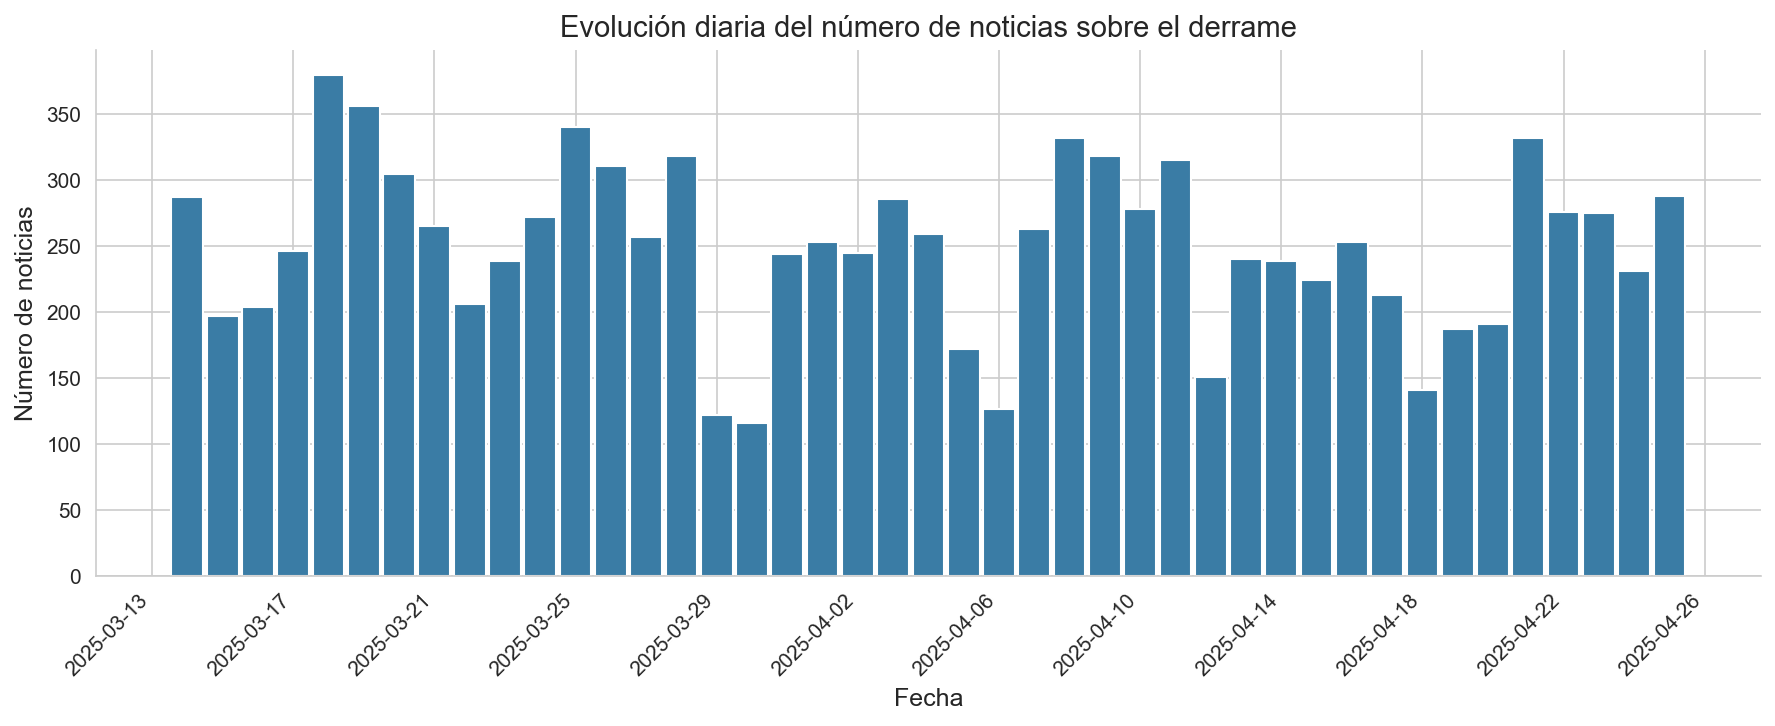

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
# Preparar datos diarios
conteo_diario = df_total.set_index('fecha').resample('D').size()
ax.bar(conteo_diario.index, conteo_diario.values, color='#3a7ca5', width=0.9)
ax.set_title('Evolución diaria del número de noticias sobre el derrame')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de noticias')
ax.xaxis.set_major_locator(MaxNLocator(nbins=15))  # Mostrar máximo 10 etiquetas
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.savefig('fig1_evolucion_temporal.pdf', format='pdf')  # Listo para publicación
plt.show()

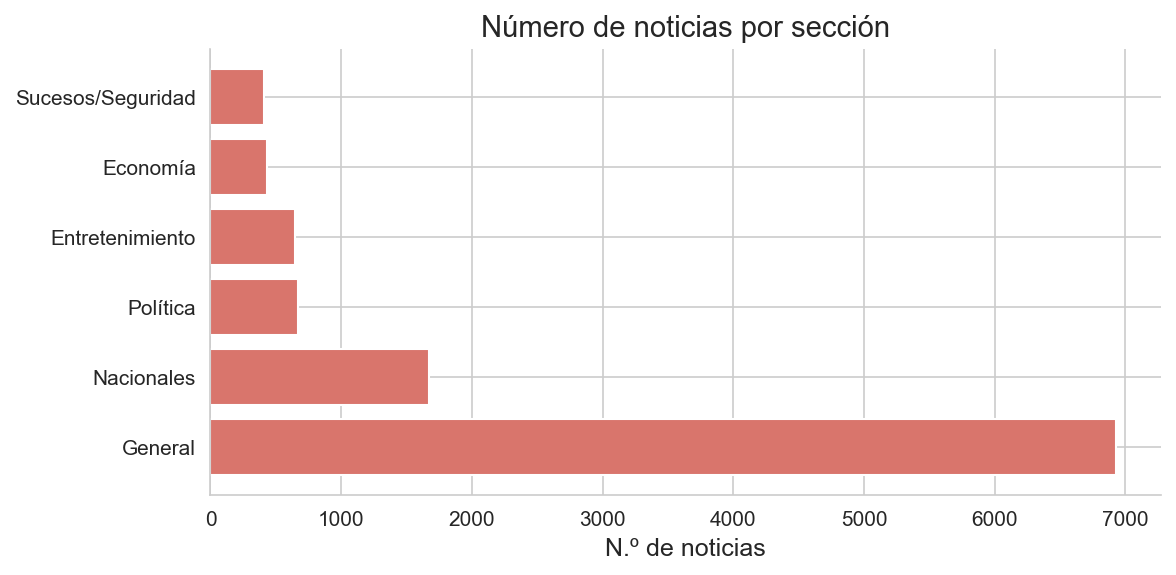

In [14]:
fig, ax = plt.subplots(figsize=(8, max(4, len(tabla_seccion)*0.5)))
orden_secciones = tabla_seccion['N.º de noticias'].argsort()  # inverso para horizontal descendente
# Reindexar para orden descendente de frecuencia
datos_ordenados = tabla_seccion.iloc[orden_secciones]

bars = ax.barh(datos_ordenados['Sección'], datos_ordenados['N.º de noticias'], color='#d9756c')
ax.set_title('Número de noticias por sección')
ax.set_xlabel('N.º de noticias')
ax.invert_yaxis()  # La más frecuente arriba
sns.despine()
plt.tight_layout()
plt.savefig('fig2_secciones.pdf', format='pdf')
plt.show()

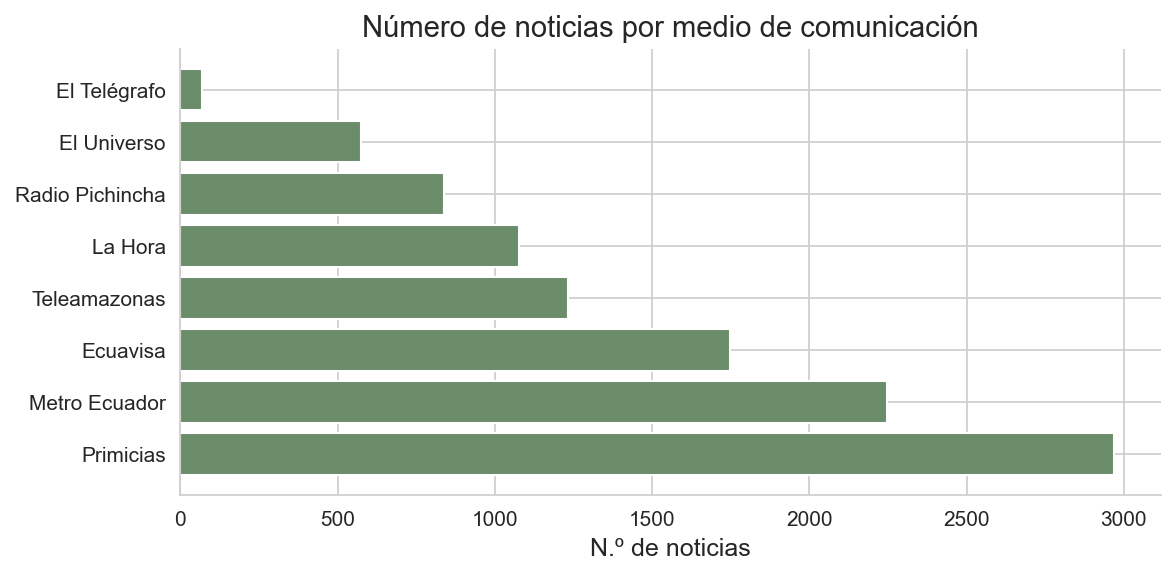

In [15]:
fig, ax = plt.subplots(figsize=(8, max(4, len(tabla_medio)*0.5)))
orden_medios = tabla_medio['N.º de noticias'].argsort()
datos_ordenados = tabla_medio.iloc[orden_medios]

bars = ax.barh(datos_ordenados['Medio'], datos_ordenados['N.º de noticias'], color='#6a8c69')
ax.set_title('Número de noticias por medio de comunicación')
ax.set_xlabel('N.º de noticias')
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig('fig3_medios.pdf', format='pdf')
plt.show()

Analizando menciones en df_total...


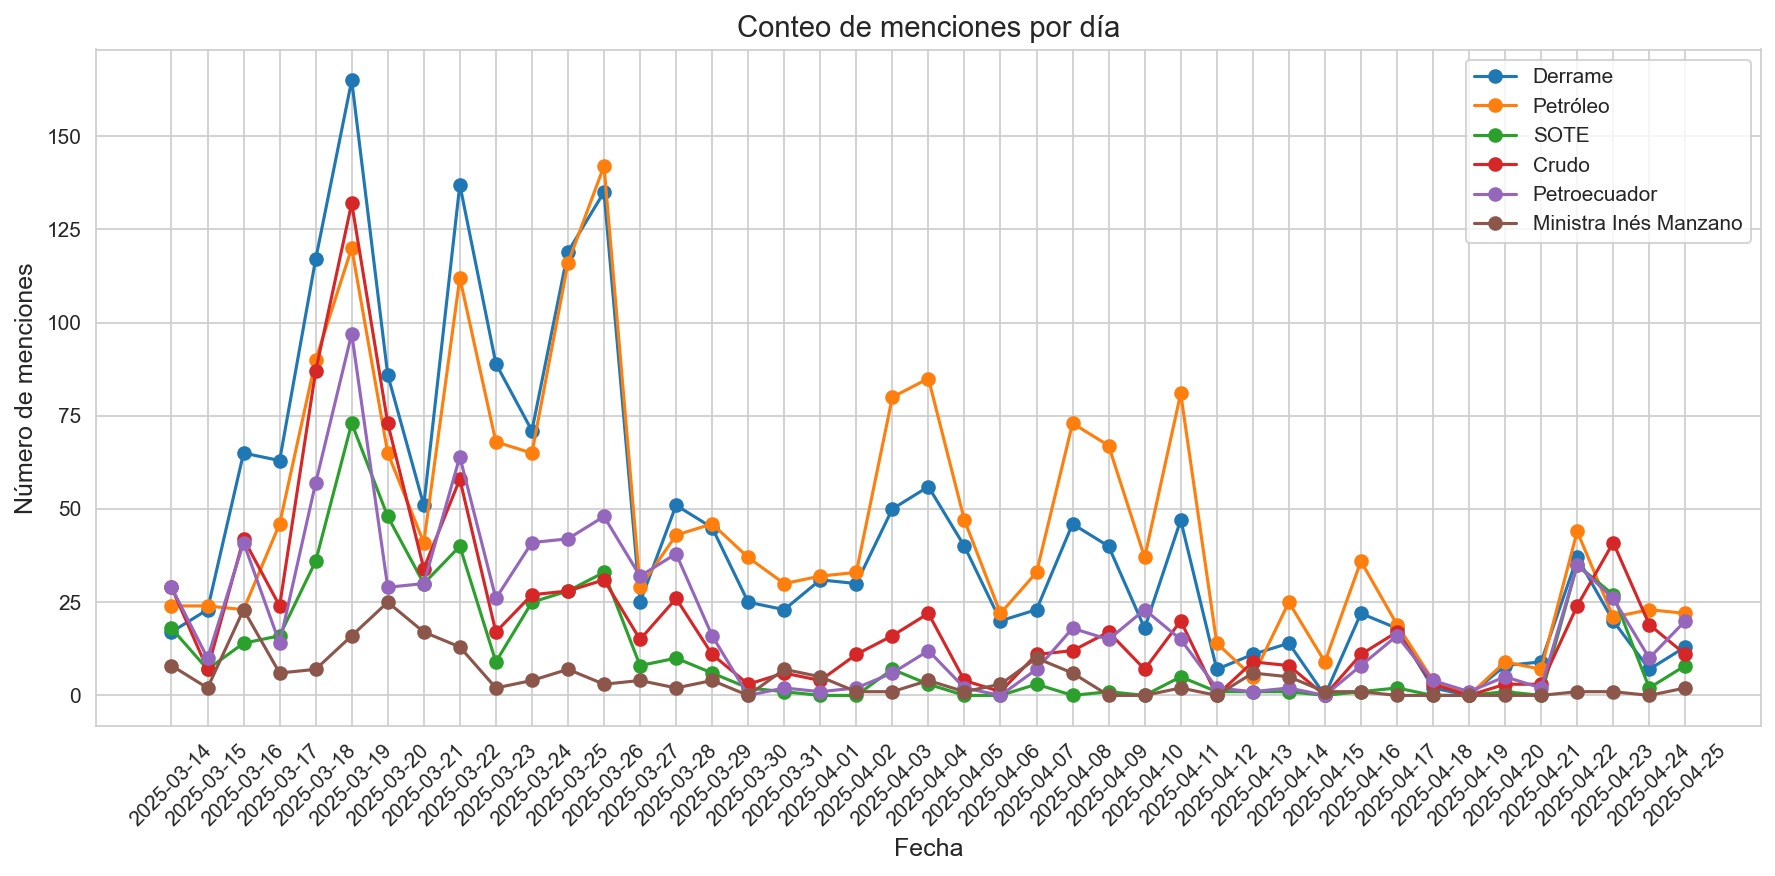

In [16]:
# --- ANÁLISIS DE MENCIONES DIARIAS DE TÉRMINOS ESPECÍFICOS ---
import re

# --- 1. CONFIGURACIÓN DE TÉRMINOS DE BÚSQUEDA ---
terms = ["derrame", "petróleo", "crudo", "SOTE", "Petroecuador", "Inés Manzano"]

# Definimos qué términos deben ser insensibles a mayúsculas (case-insensitive)
# Es más limpio tenerlos en una lista o set aparte para modificarlo fácilmente.
terms_case_insensitive = {"derrame", "petróleo", "crudo"}  # SOTE y Petroecuador se mantendrán case-sensitive por ser siglas/nombres propios

lista_datos = []

# Usamos df_total que ya contiene todo el rango de fechas
print("Analizando menciones en df_total...")

# --- 2. PROCESAMIENTO ---
# Agrupamos por fecha (día)
grouped = df_total.groupby(df_total['fecha'].dt.date)

for fecha, group in grouped:
    fecha_str = fecha.strftime('%Y-%m-%d')
    
    # Diccionario para almacenar los conteos de ESTE día
    conteo_dia = {'Fecha': fecha_str}
    
    for term in terms:
        # Determinar si usamos IGNORECASE basándonos en la lista de configuración
        flags = re.IGNORECASE if term in terms_case_insensitive else 0
        
        # Contamos las ocurrencias (usando \b para palabra completa) en el grupo del día
        total_mentions = group['cuerpo'].str.count(
            rf'\b{term}\b', 
            flags=flags
        ).sum()
        
        conteo_dia[term] = total_mentions
    
    lista_datos.append(conteo_dia)

# --- 3. CREACIÓN DEL DATAFRAME FINAL ---
df_menciones = pd.DataFrame(lista_datos)

if not df_menciones.empty:
    # Rellenar con 0 si en algún caso extraño faltara un dato y asegurar orden de columnas
    df_menciones = df_menciones.fillna(0)
    
    # Ordenar columnas: Fecha primero, luego los términos
    cols = ['Fecha'] + [col for col in df_menciones.columns if col != 'Fecha']
    df_menciones = df_menciones[cols]

# --- 4. Graficar trayectoria de menciones por día
plt.figure(figsize=(12, 6))
plt.plot(df_menciones['Fecha'], df_menciones['derrame'], marker='o', label='Derrame')
plt.plot(df_menciones['Fecha'], df_menciones['petróleo'], marker='o', label='Petróleo')
plt.plot(df_menciones['Fecha'], df_menciones['SOTE'], marker='o', label='SOTE')
plt.plot(df_menciones['Fecha'], df_menciones['crudo'], marker='o', label='Crudo')
plt.plot(df_menciones['Fecha'], df_menciones['Petroecuador'], marker='o', label='Petroecuador')
plt.plot(df_menciones['Fecha'], df_menciones['Inés Manzano'], marker='o', label='Ministra Inés Manzano')
plt.xlabel('Fecha')
plt.ylabel('Número de menciones')
plt.title('Conteo de menciones por día')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Dimensión 1: Indicadores Estructurales

Esta sección cuantifica la arquitectura base del corpus: cuánta información contienen los textos, cómo se distribuye entre titular y cuerpo, la riqueza vocabular y la presencia de entidades nombradas. Cada indicador se presenta con su justificación conceptual, metodología, resultado esperado para el caso del derrame de Esmeraldas y posibles interpretaciones.


In [17]:
# Celda de configuración: importaciones, carga de modelos y funciones base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')

# Estilo visual para todas las figuras (revista Q1)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})
sns.set_style("whitegrid")
PALETA = sns.color_palette("muted")

# Carga de modelo spaCy en español (asegurar instalación previa)
import spacy
try:
    nlp = spacy.load("es_core_news_lg")
except OSError:
    print("Modelo 'es_core_news_lg' no encontrado. Descargando...")
    import subprocess
    subprocess.run(["python", "-m", "spacy", "download", "es_core_news_lg"])
    nlp = spacy.load("es_core_news_lg")

# Función auxiliar: tokenización con spaCy (cálculo de tokens sin stopwords ni puntuación)
def tokenizar_spacy(texto, remover_stopwords=True, remover_punct=True):
    doc = nlp(texto if isinstance(texto, str) else "")
    tokens = []
    for token in doc:
        if remover_punct and token.is_punct:
            continue
        if remover_stopwords and token.is_stop:
            continue
        tokens.append(token.lemma_.lower())
    return tokens

# Se asume que df_total ya está cargado y contiene las columnas:
# 'fecha', 'medio', 'seccion', 'titular', 'cuerpo'
print("Configuración completada. Dimensiones del corpus:", df_total.shape)

Configuración completada. Dimensiones del corpus: (10754, 6)


### 1. Densidad Informativa

**🔍 Interpretación conceptual**  
Mide la proporción de unidades léxicas significativas (tokens) respecto a la longitud bruta del texto (caracteres, excluyendo espacios). Una alta densidad sugiere un lenguaje cargado de conceptos, típico de notas técnicas o comunicados oficiales; una baja densidad puede indicar relleno discursivo o estilo narrativo más pausado.

**⚙️ Metodología de cálculo**

1. Para cada noticia, se calcula el total de caracteres visibles (sin espacios en blanco) y el total de tokens léxicos (lematizados, sin stopwords ni puntuación).
2. La densidad se define como frac{text{total tokens}\}{\text{total caracteres}\}.
3. Se agrupa por medio y por sección para obtener distribuciones.
4. Se visualiza mediante gráficos de densidad (KDE) y se reportan estadísticos descriptivos.

**🎯 Resultado esperado para el derrame de Esmeraldas (2025)**  
Se anticipa una densidad media‑alta en la cobertura del derrame (0.12‑0.18), especialmente en noticias de secciones de “ambiente” y “política”, debido a la alta presencia de terminología técnica (crudo, ecosistema, mitigación) y nombres propios (Petroecuador, Esmeraldas, comunidades). Los comunicados institucionales y las noticias de agencia mostrarán densidades más elevadas.

**📖 Posibles interpretaciones y hipótesis derivadas**

- Valores bajos (<0.10): posible presencia de notas de relleno, transcripciones de discursos extensos o reportajes con largas citas narrativas.
- Valores altos (>0.20): indican textos muy compactos, posiblemente técnicos o institucionales, que podrían estar dirigidos a audiencias especializadas.
- Diferencias entre medios: medios locales pueden mostrar menor densidad por un estilo más narrativo y cercano a la crónica; medios nacionales, mayor densidad en notas de agencia.


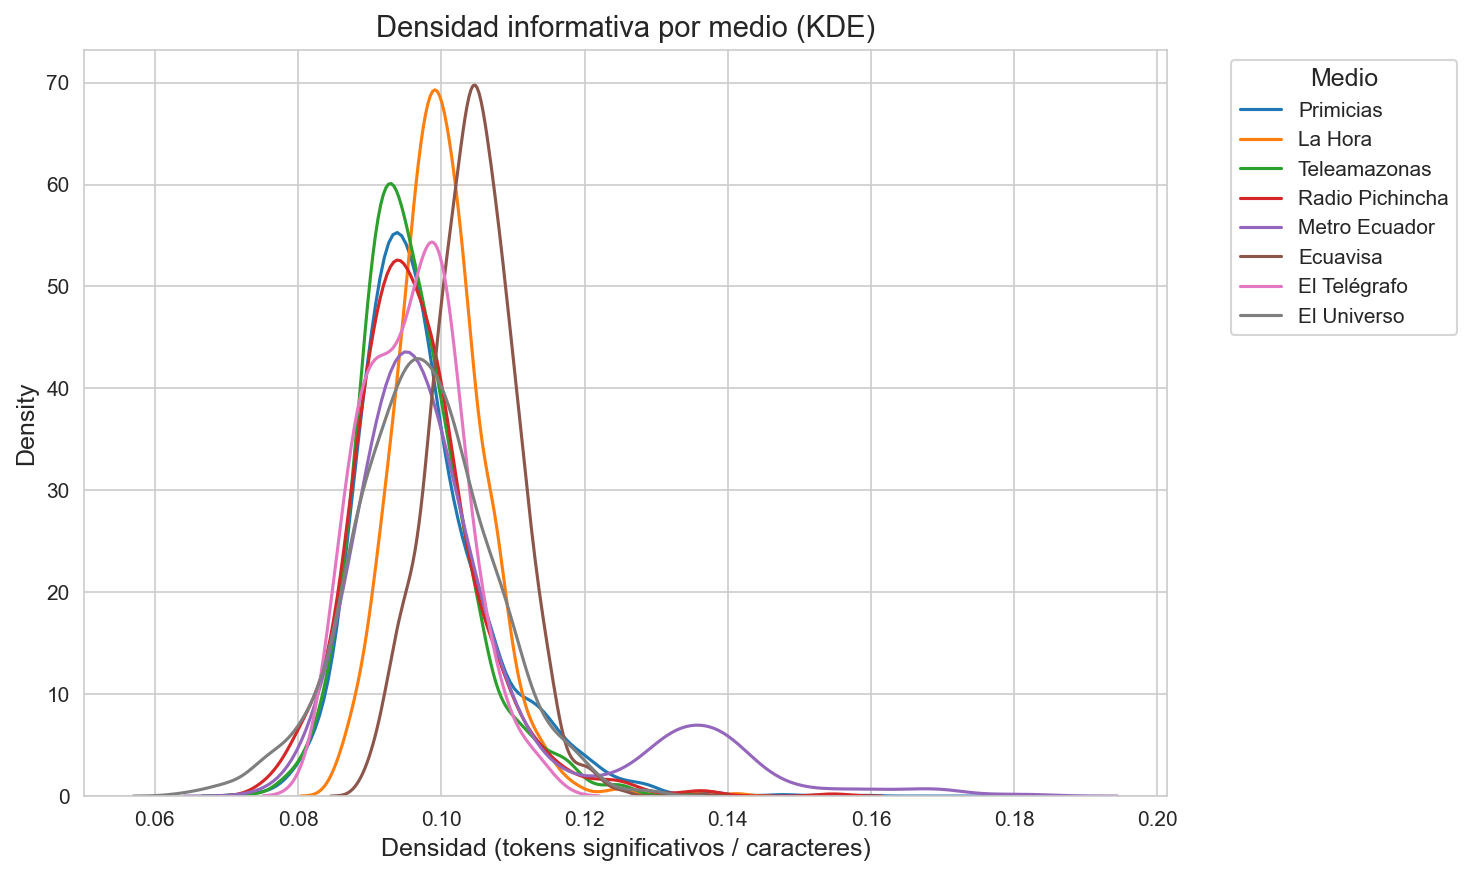

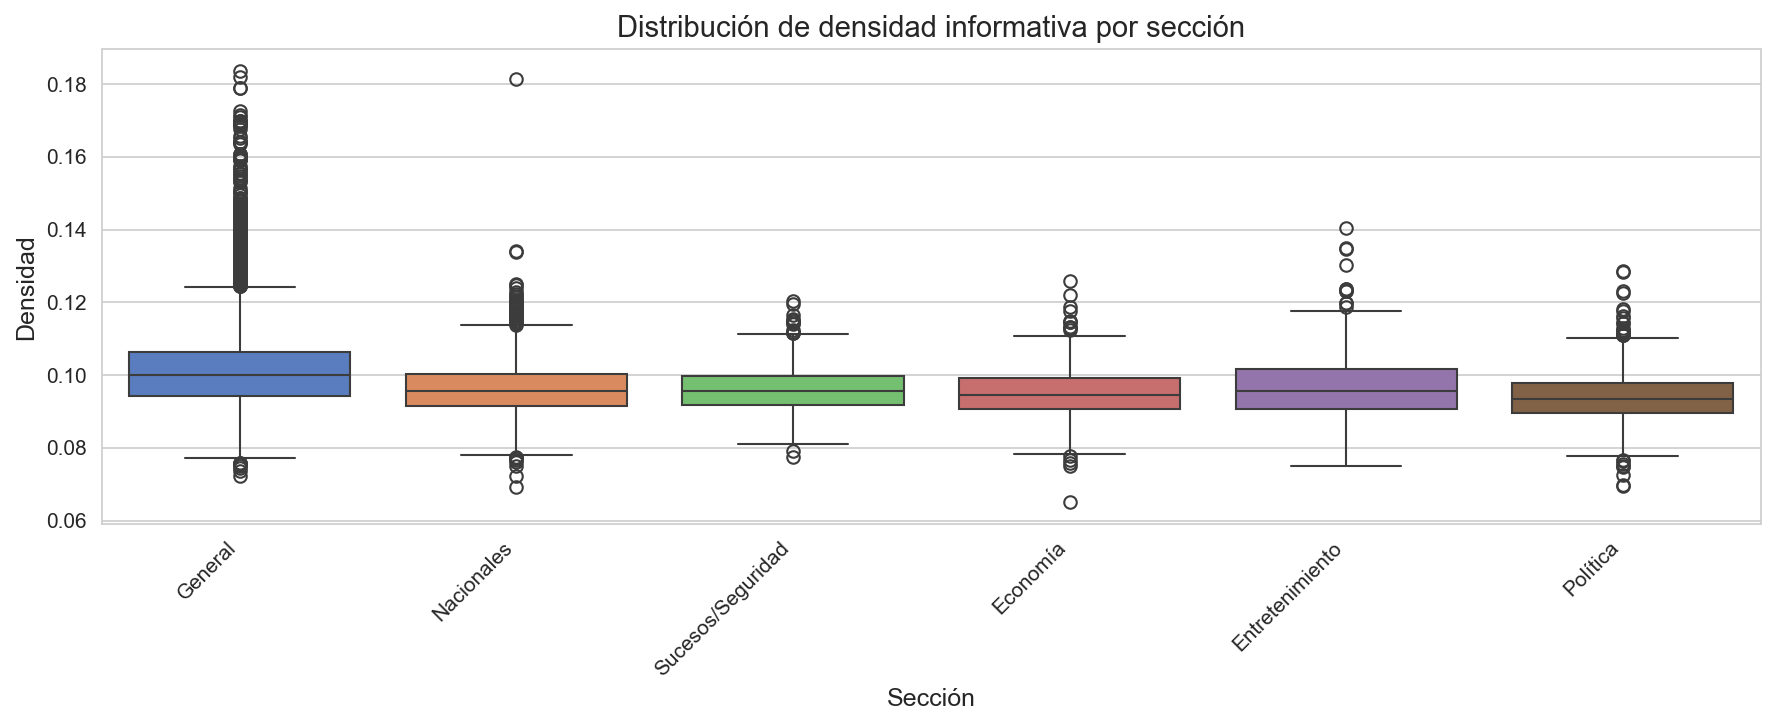

,count,mean,std,min,25%,50%,75%,max
medio,,,,,,,,
Ecuavisa,1749.0000,0.1045,0.0060,0.0886,0.1007,0.1046,0.1084,0.1362
El Telégrafo,69.0000,0.0961,0.0066,0.0836,0.0906,0.0967,0.1007,0.1135
El Universo,574.0000,0.0973,0.0096,0.0650,0.0909,0.0972,0.1031,0.1287
La Hora,1076.0000,0.1000,0.0063,0.0850,0.0959,0.0996,0.1035,0.1412
Metro Ecuador,2247.0000,0.1025,0.0169,0.0749,0.0923,0.0973,0.1050,0.1836
Primicias,2970.0000,0.0975,0.0093,0.0723,0.0914,0.0958,0.1017,0.1813
Radio Pichincha,837.0000,0.0963,0.0088,0.0755,0.0908,0.0952,0.1006,0.1546
Teleamazonas,1232.0000,0.0961,0.0077,0.0723,0.0909,0.0949,0.1002,0.1338


,count,mean,std,min,25%,50%,75%,max
seccion,,,,,,,,
Economía,432.0000,0.0952,0.0075,0.0650,0.0907,0.0945,0.0991,0.1259
Entretenimiento,646.0000,0.0965,0.0086,0.0751,0.0906,0.0957,0.1016,0.1404
General,6926.0000,0.1018,0.0119,0.0723,0.0944,0.1000,0.1063,0.1836
Nacionales,1669.0000,0.0962,0.0077,0.0693,0.0914,0.0955,0.1003,0.1813
Política,670.0000,0.0942,0.0074,0.0696,0.0895,0.0933,0.0979,0.1287
Sucesos/Seguridad,411.0000,0.0961,0.0065,0.0774,0.0917,0.0955,0.0996,0.1204


In [ ]:
def calcular_densidad_informativa(df):
    """Calcula la densidad informativa para cada fila del corpus."""
    df = df.copy()
    # Caracteres sin espacios
    df['caracteres'] = df['cuerpo'].astype(str).str.replace(r'\s+', '', regex=True).str.len()
    # Tokens significativos (lematizados, sin stopwords ni puntuación)
    # Para agilizar, se puede usar una versión con nlp.pipe (por lotes)
    docs = list(nlp.pipe(df['cuerpo'].astype(str), batch_size=50, n_process=1))
    tokens_por_doc = []
    for doc in docs:
        tokens = [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_stop]
        tokens_por_doc.append(len(tokens))
    df['tokens_signif'] = tokens_por_doc
    
    # Densidad: tokens significativos / caracteres (evitar división por cero)
    df['densidad'] = df['tokens_signif'] / df['caracteres'].replace(0, np.nan)
    df['densidad'] = df['densidad'].fillna(0)
    return df

# Ejecutar cálculo (puede tomar tiempo según el tamaño del corpus)
df_kpi1 = calcular_densidad_informativa(df_total)

# Visualización 1: KDE por medio
plt.figure(figsize=(10, 6))
for medio in df_kpi1['medio'].unique():
    subset = df_kpi1[df_kpi1['medio'] == medio]['densidad'].dropna()
    if len(subset) > 5:
        sns.kdeplot(subset, label=medio, linewidth=1.5)
plt.title('Densidad informativa por medio (KDE)')
plt.xlabel('Densidad (tokens significativos / caracteres)')
plt.legend(title='Medio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('kpi1_densidad_por_medio.pdf', format='pdf')
plt.savefig('kpi1_densidad_por_medio.png', dpi=300)
plt.show()

# Visualización 2: boxplot por sección
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_kpi1, x='seccion', y='densidad', palette='muted')
plt.title('Distribución de densidad informativa por sección')
plt.xlabel('Sección')
plt.ylabel('Densidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Tabla resumen por medio
resumen_medio = df_kpi1.groupby('medio')['densidad'].describe()
display(resumen_medio.style.set_caption("Estadísticos de densidad informativa por medio").format('{:.4f}'))
# Tabla resumen por sección
resumen_seccion = df_kpi1.groupby('seccion')['densidad'].describe()
display(resumen_seccion.style.set_caption("Estadísticos de densidad informativa por sección").format('{:.4f}'))

### 2. Ratio Titular/Cuerpo

**🔍 Interpretación conceptual**  
El ratio entre la cantidad de tokens del titular y la del cuerpo revela la carga informativa del encabezado en relación con el desarrollo de la noticia. Un ratio alto indica titulares densos que condensan mucha información (típicos en alertas de última hora o comunicados urgentes), mientras que un ratio bajo refleja titulares breves y desarrollos extensos (propios de reportajes o crónicas).

**⚙️ Metodología de cálculo**

1. Se tokeniza por separado el titular y el cuerpo de cada noticia, contando únicamente tokens léxicos (lematizados, sin stopwords ni puntuación).
2. Se calcula el ratio: `\text{Ratio} = \frac{\text{tokens del titular}}{\text{tokens del cuerpo}}`.
3. Se agrega por medio, presentando diagramas de caja para visualizar la dispersión y tablas con estadísticos descriptivos.

**🎯 Resultado esperado para el derrame de Esmeraldas (2025)**  
Se espera que en los primeros días de la crisis los ratios sean más elevados (titulares extensos y alarmistas, cuerpos breves por la inmediatez). Con el paso de los días, el ratio disminuirá a medida que aparecen artículos de análisis o reportajes de fondo. Los medios locales podrían mantener ratios más altos por noticias más cortas y directas.

**📖 Posibles interpretaciones y hipótesis derivadas**

- Ratio > 0.15: posiblemente notas urgentes, cables de agencia o titulares‑resumen.
- Ratio < 0.05: indica artículos con gran desarrollo narrativo o contextual, potencialmente investigaciones o crónicas.
- Comparación entre secciones: “Política” podría presentar ratios variables según la naturaleza de la noticia (declaraciones breves vs. análisis), mientras que “Ambiente” tendería a ratios más bajos por el detalle técnico.


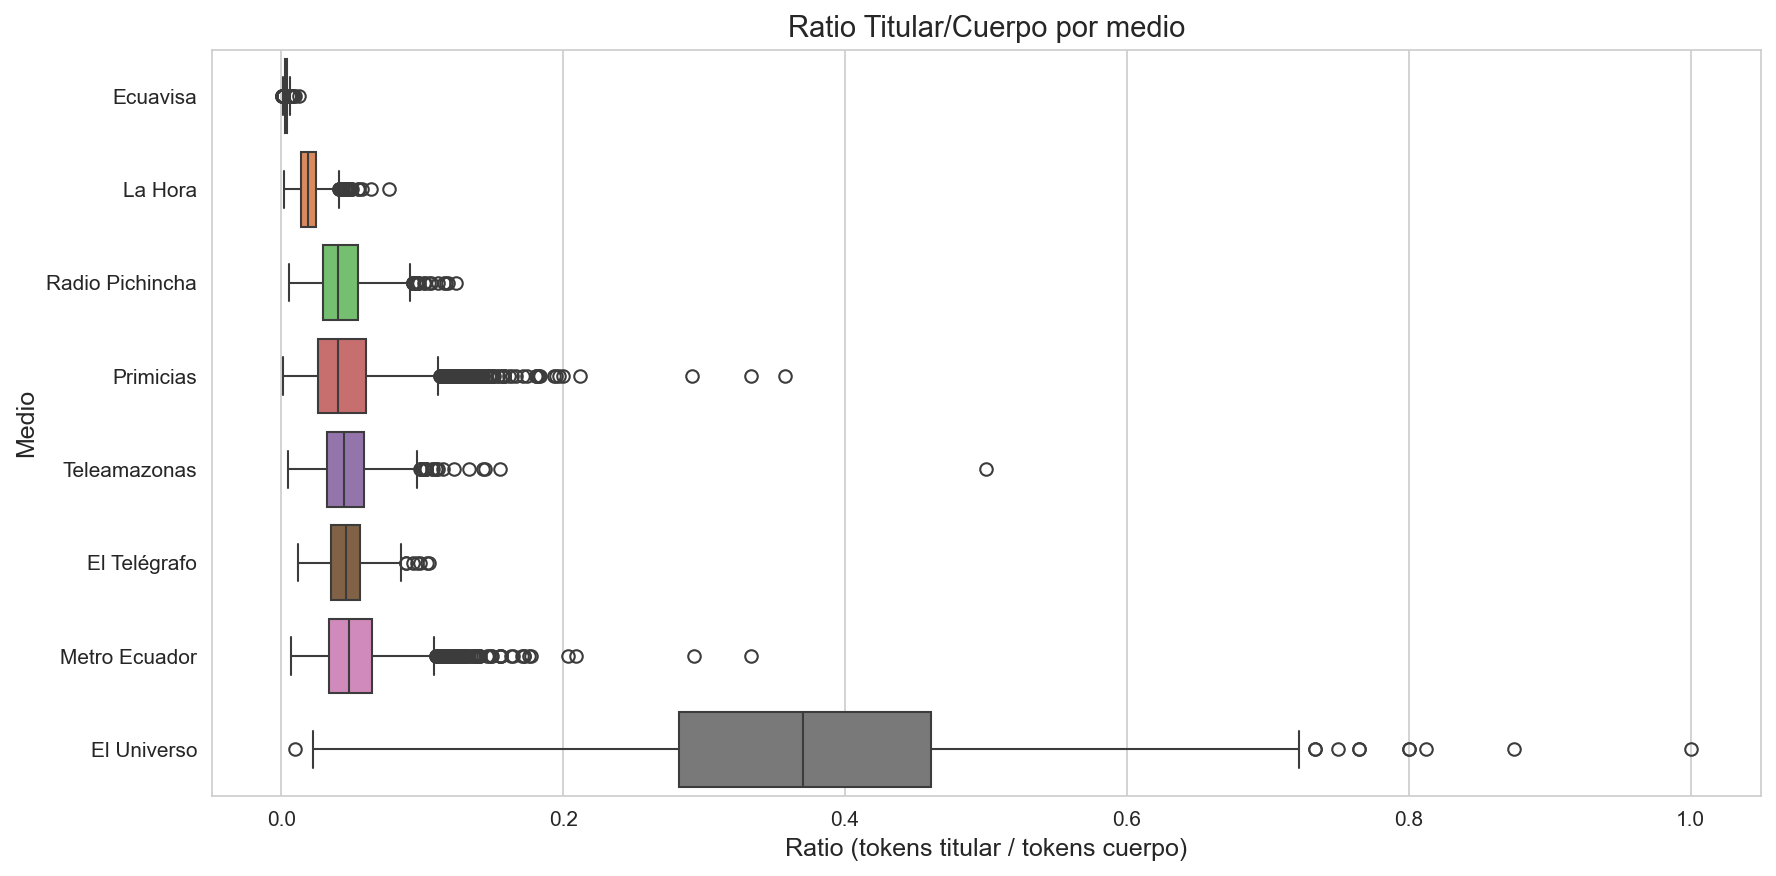

,count,mean,std,min,25%,50%,75%,max
medio,,,,,,,,
Ecuavisa,1749.0000,0.0035,0.0011,0.0005,0.0029,0.0035,0.0041,0.0123
El Telégrafo,69.0000,0.0500,0.0220,0.0114,0.0349,0.0462,0.0561,0.1045
El Universo,574.0000,0.3739,0.1409,0.0098,0.2824,0.3704,0.4607,1.0000
La Hora,1076.0000,0.0203,0.0090,0.0022,0.0141,0.0188,0.0248,0.0764
Metro Ecuador,2247.0000,0.0525,0.0273,0.0067,0.0336,0.0481,0.0640,0.3333
Primicias,2970.0000,0.0471,0.0318,0.0012,0.0256,0.0404,0.0600,0.3571
Radio Pichincha,837.0000,0.0435,0.0201,0.0054,0.0294,0.0403,0.0545,0.1236
Teleamazonas,1232.0000,0.0473,0.0240,0.0049,0.0325,0.0444,0.0588,0.5000


In [ ]:
def calcular_ratio_titular_cuerpo(df):
    """Calcula el ratio titular/cuerpo basado en tokens significativos."""
    df = df.copy()
    # Tokenizar titulares
    tit_docs = list(nlp.pipe(df['titular'].astype(str), batch_size=100, n_process=1))
    token_titular = [len([t.lemma_.lower() for t in doc if not t.is_punct and not t.is_stop]) for doc in tit_docs]
    # Tokenizar cuerpos (ya calculado en KPI1, pero para independencia lo rehacemos)
    cu_docs = list(nlp.pipe(df['cuerpo'].astype(str), batch_size=50, n_process=1))
    token_cuerpo = [len([t.lemma_.lower() for t in doc if not t.is_punct and not t.is_stop]) for doc in cu_docs]
    
    df['tokens_titular'] = token_titular
    df['tokens_cuerpo'] = token_cuerpo
    df['ratio_tc'] = df['tokens_titular'] / df['tokens_cuerpo'].replace(0, np.nan)
    df['ratio_tc'] = df['ratio_tc'].fillna(0)
    return df

df_kpi2 = calcular_ratio_titular_cuerpo(df_total)

# Visualización: boxplot por medio
plt.figure(figsize=(12, 6))
orden_medios = df_kpi2.groupby('medio')['ratio_tc'].median().sort_values().index
sns.boxplot(data=df_kpi2, y='medio', x='ratio_tc', order=orden_medios, palette='muted')
plt.title('Ratio Titular/Cuerpo por medio')
plt.xlabel('Ratio (tokens titular / tokens cuerpo)')
plt.ylabel('Medio')
plt.tight_layout()
plt.show()

# Tabla resumen por medio
resumen_ratio = df_kpi2.groupby('medio')['ratio_tc'].describe()
display(resumen_ratio.style.set_caption("Estadísticos del ratio Titular/Cuerpo por medio").format('{:.4f}'))

### 3. Diversidad Léxica (Type‑Token Ratio) por Medio

**🔍 Interpretación conceptual**  
La riqueza vocabular, medida a través del Type‑Token Ratio (TTR), cuantifica la proporción de palabras únicas (types) frente al total de palabras (tokens) en un texto. Un TTR alto indica un vocabulario variado y discurso con múltiples enfoques; un TTR bajo sugiere repetición de términos, posiblemente debido a un marco narrativo uniforme o limitado.

**⚙️ Metodología de cálculo**

1. Se tokeniza y lematiza cada noticia, eliminando stopwords y signos de puntuación.
2. Por documento, se calcula el número de lemas únicos (types) y el total de lemas (tokens). El TTR es `\frac{\text{types}}{\text{tokens}}`.
3. Se agrega por medio, computando la media y el intervalo de confianza al 95% (suponiendo distribución normal aproximada).
4. Se presenta un gráfico de barras con barras de error.

**🎯 Resultado esperado para el derrame de Esmeraldas (2025)**  
Los medios especializados en temática ambiental o locales podrían presentar TTR más alto (>0.35) gracias a un léxico específico (ecosistema, manglar, comunidad, mitigación). Los medios generalistas nacionales mostrarán TTR moderados (0.25‑0.35) debido a una mezcla de terminología técnica y lenguaje noticioso estándar. Las noticias de agencia tienden a repetir palabras clave, bajando el TTR.

**📖 Posibles interpretaciones y hipótesis derivadas**

- TTR cercano a 0.5 o superior: indica altísima diversidad léxica, quizás por artículos que combinan múltiples dimensiones (social, económica, política).
- TTR inferior a 0.2: sugiere una cobertura monocorde, posiblemente dominada por un solo encuadre o fuente.
- La comparación entre secciones y medios permite detectar si ciertos actores mediáticos “empobrecen” el discurso al repetir marcos.


Calculando tokens por documento para TTR...


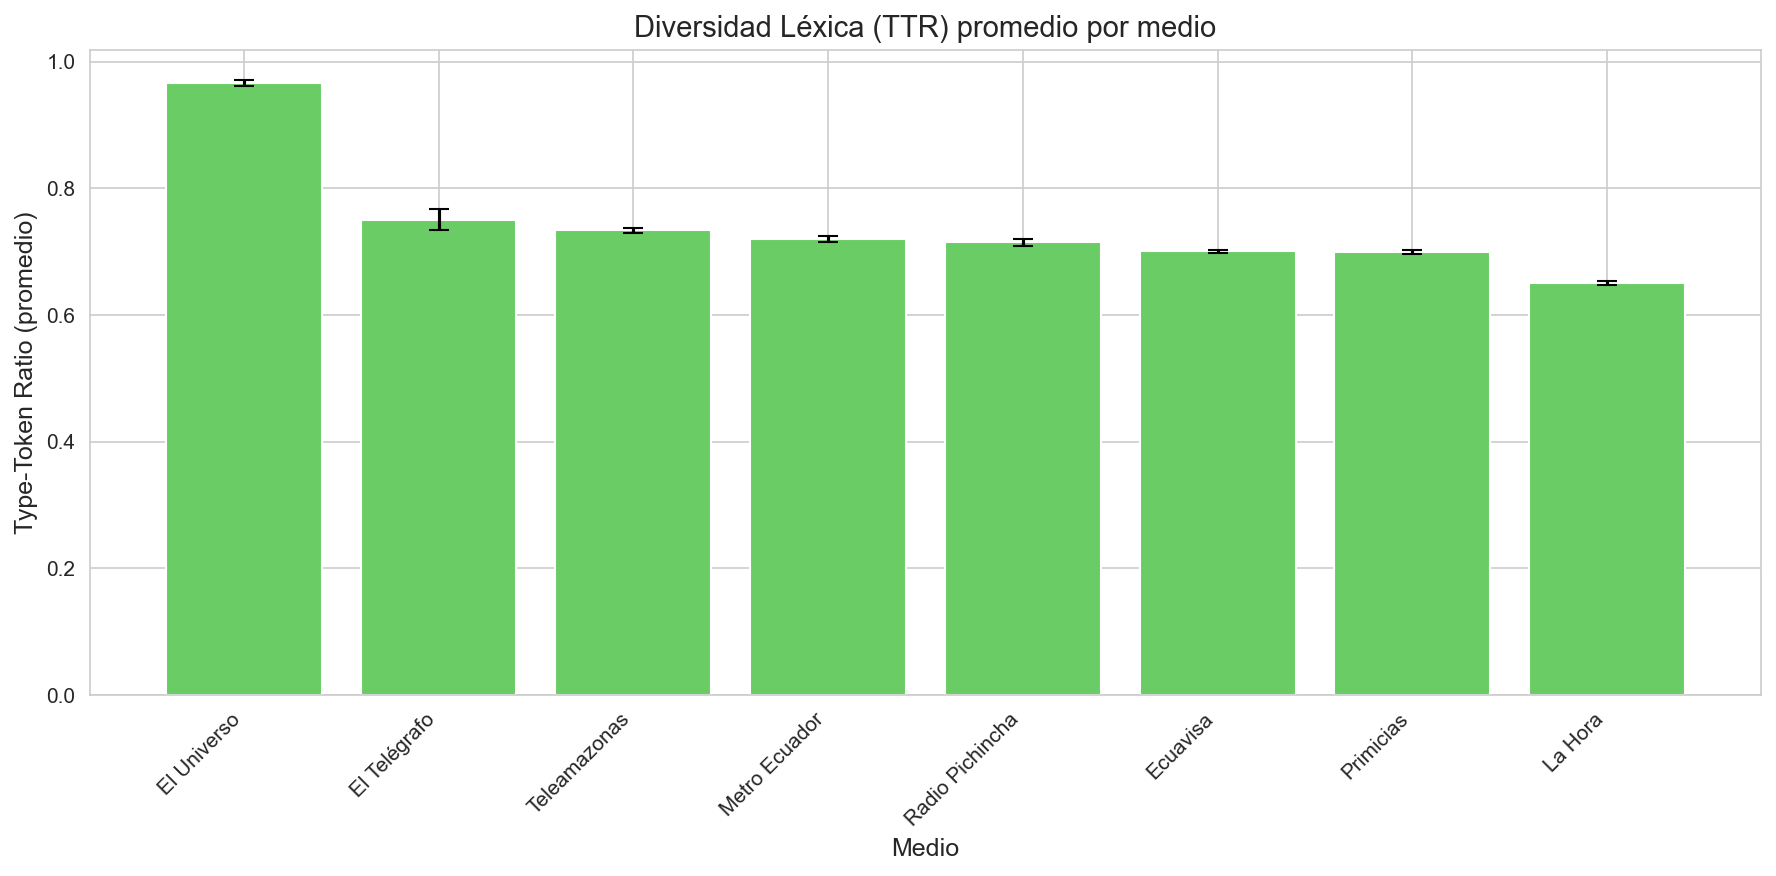

,mean,std,count,error
medio,,,,
El Universo,0.966,0.058,574,0.005
El Telégrafo,0.750,0.071,69,0.017
Teleamazonas,0.734,0.070,1232,0.004
Metro Ecuador,0.719,0.114,2247,0.005
Radio Pichincha,0.715,0.083,837,0.006
Ecuavisa,0.701,0.053,1749,0.002
Primicias,0.700,0.095,2970,0.003
La Hora,0.650,0.062,1076,0.004


In [ ]:
def calculate_ttr(tokens_list):
    """Calcula TTR para una lista de tokens (ya lematizados y filtrados)."""
    total = len(tokens_list)
    if total == 0:
        return 0
    return len(set(tokens_list)) / total

# Obtener listas de tokens por documento (lematizados, sin stopwords/punct)
# Usamos los docs ya generados en KPI1 para evitar reprocesamiento; si no existen, reprocesar.
# Asumimos que 'df_kpi1' tiene la columna 'tokens_signif' pero no los tokens en sí.
# Para TTR necesitamos los tokens. Usaremos una nueva extracción.
print("Calculando tokens por documento para TTR...")
docs = list(nlp.pipe(df_total['cuerpo'].astype(str), batch_size=50, n_process=1))
ttr_series = []
for doc in docs:
    tokens = [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_stop]
    ttr_series.append(calculate_ttr(tokens))

df_ttr = df_total[['medio', 'seccion']].copy()
df_ttr['TTR'] = ttr_series

# Agregación por medio: mediana, media, IC 95%
from scipy import stats
agrupado_medio = df_ttr.groupby('medio')['TTR']
ttr_stats = agrupado_medio.agg(['mean', 'std', 'count'])
ttr_stats['error'] = ttr_stats['std'] / np.sqrt(ttr_stats['count']) * 1.96  # IC 95%

# Ordenar por media descendente para el gráfico
ttr_stats = ttr_stats.sort_values('mean', ascending=False)

# Gráfico de barras con error bars
plt.figure(figsize=(12, 6))
barras = plt.bar(ttr_stats.index, ttr_stats['mean'], yerr=ttr_stats['error'], 
                 color=sns.color_palette("muted")[2], capsize=5)
plt.title('Diversidad Léxica (TTR) promedio por medio')
plt.ylabel('Type-Token Ratio (promedio)')
plt.xlabel('Medio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Tabla resumen
display(ttr_stats.style.set_caption("Estadísticos de TTR por medio con IC 95%").format({'mean':'{:.3f}', 'std':'{:.3f}', 'count':'{:.0f}', 'error':'{:.3f}'}))

### 4. Proporción de Entidades Nombradas

**🔍 Interpretación conceptual**  
La densidad de entidades nombradas (personas, organizaciones, lugares, fechas, etc.) en el texto refleja el grado de anclaje del discurso en actores y realidades concretas. Una proporción elevada de entidades indica un discurso centrado en protagonistas y escenarios específicos, mientras que una baja densidad puede denotar un enfoque abstracto o técnico sin referentes explícitos.

**⚙️ Metodología de cálculo**

1. Se utiliza el reconocimiento de entidades nombradas (NER) del modelo spaCy en español sobre el cuerpo de cada noticia.
2. Para cada documento se cuenta el total de entidades detectadas y se normaliza dividiendo entre el total de tokens significativos del texto.
3. Se desglosa la proporción por tipo de entidad (`PER`, `ORG`, `LOC`, `MISC`) y se agrega por medio y sección.
4. Se visualiza mediante un heatmap (medio vs. tipo de entidad) y gráficos de barras apiladas.

**🎯 Resultado esperado para el derrame de Esmeraldas (2025)**  
Se prevé una alta densidad de entidades `ORG` (Petroecuador, Ministerio de Ambiente, ONG), `LOC` (Esmeraldas, ríos afectados, cantones) y `PER` (líderes comunitarios, ministros). La proporción total de entidades podría situarse entre 0.12 y 0.25. Los picos de `PER` pueden coincidir con declaraciones de figuras públicas, mientras que la presencia estable de `ORG` y `LOC` enfatizará la dimensión institucional y geográfica.

**📖 Posibles interpretaciones y hipótesis derivadas**

- Alta proporción de `ORG` en un medio: posiblemente cobertura enfocada en la responsabilidad institucional o corporativa.
- Alta proporción de `LOC`: sugiere énfasis en los territorios afectados, propio de medios locales o de periodismo ambiental.
- Proporción total baja: puede indicar un discurso abstracto, centrado en procesos o conceptos sin actores identificables.
- El heatmap revelará si ciertos medios ignoran sistemáticamente determinados tipos de actores.


Aplicando NER al corpus (puede tomar varios minutos)...


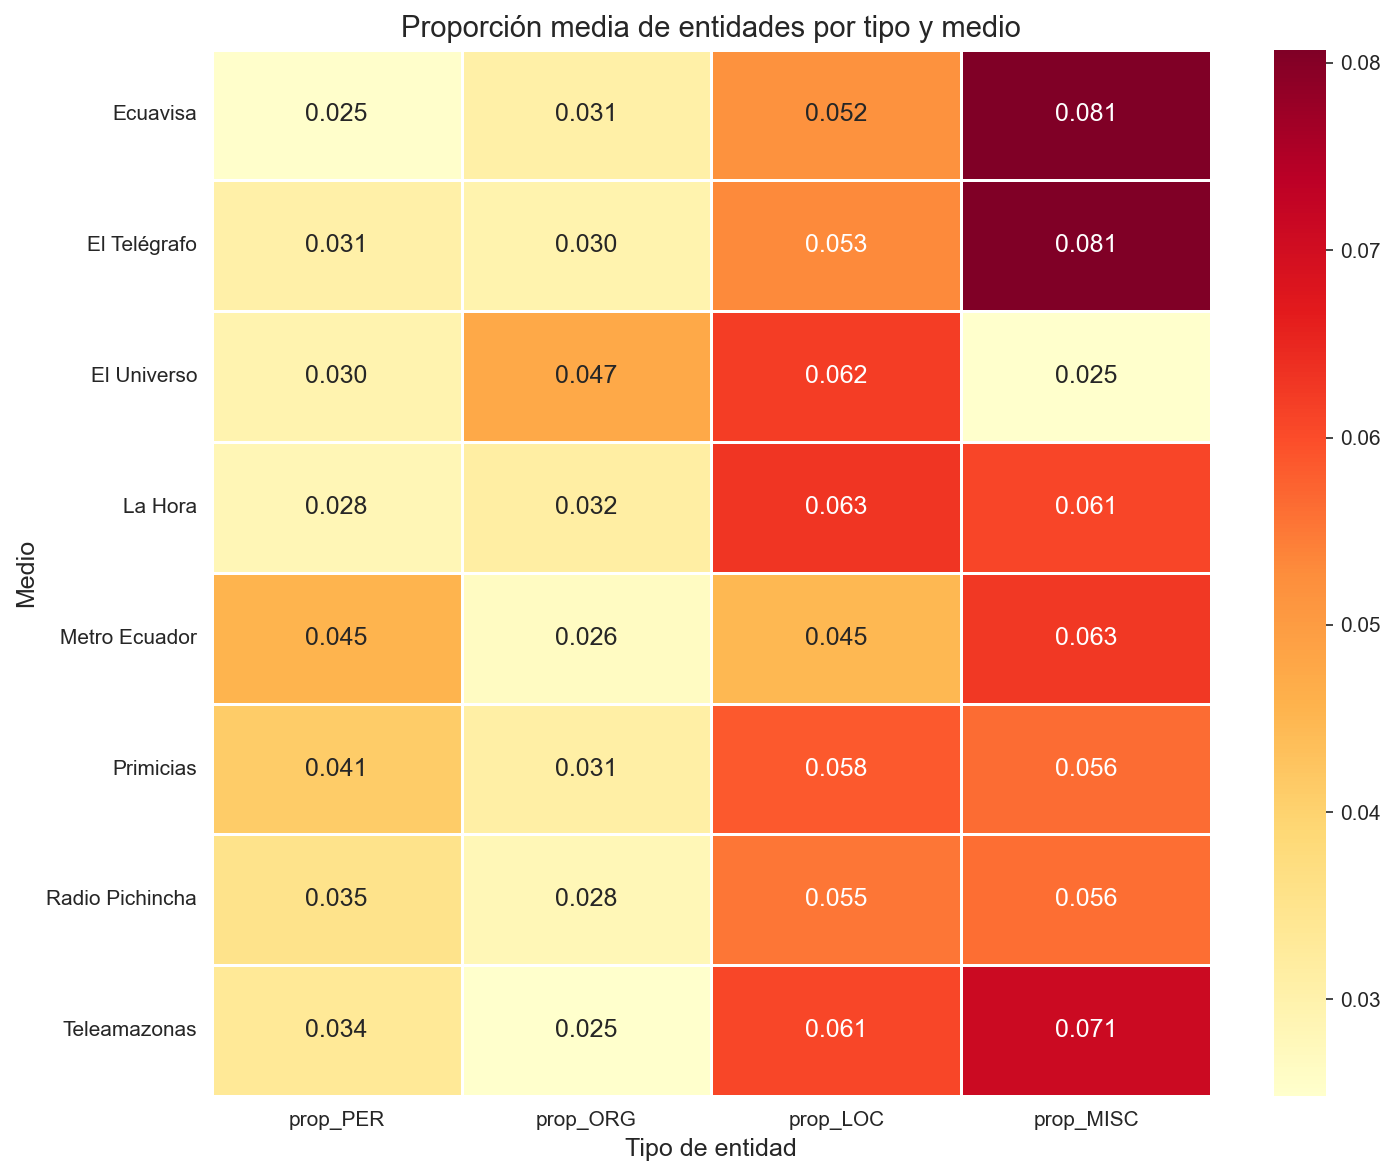

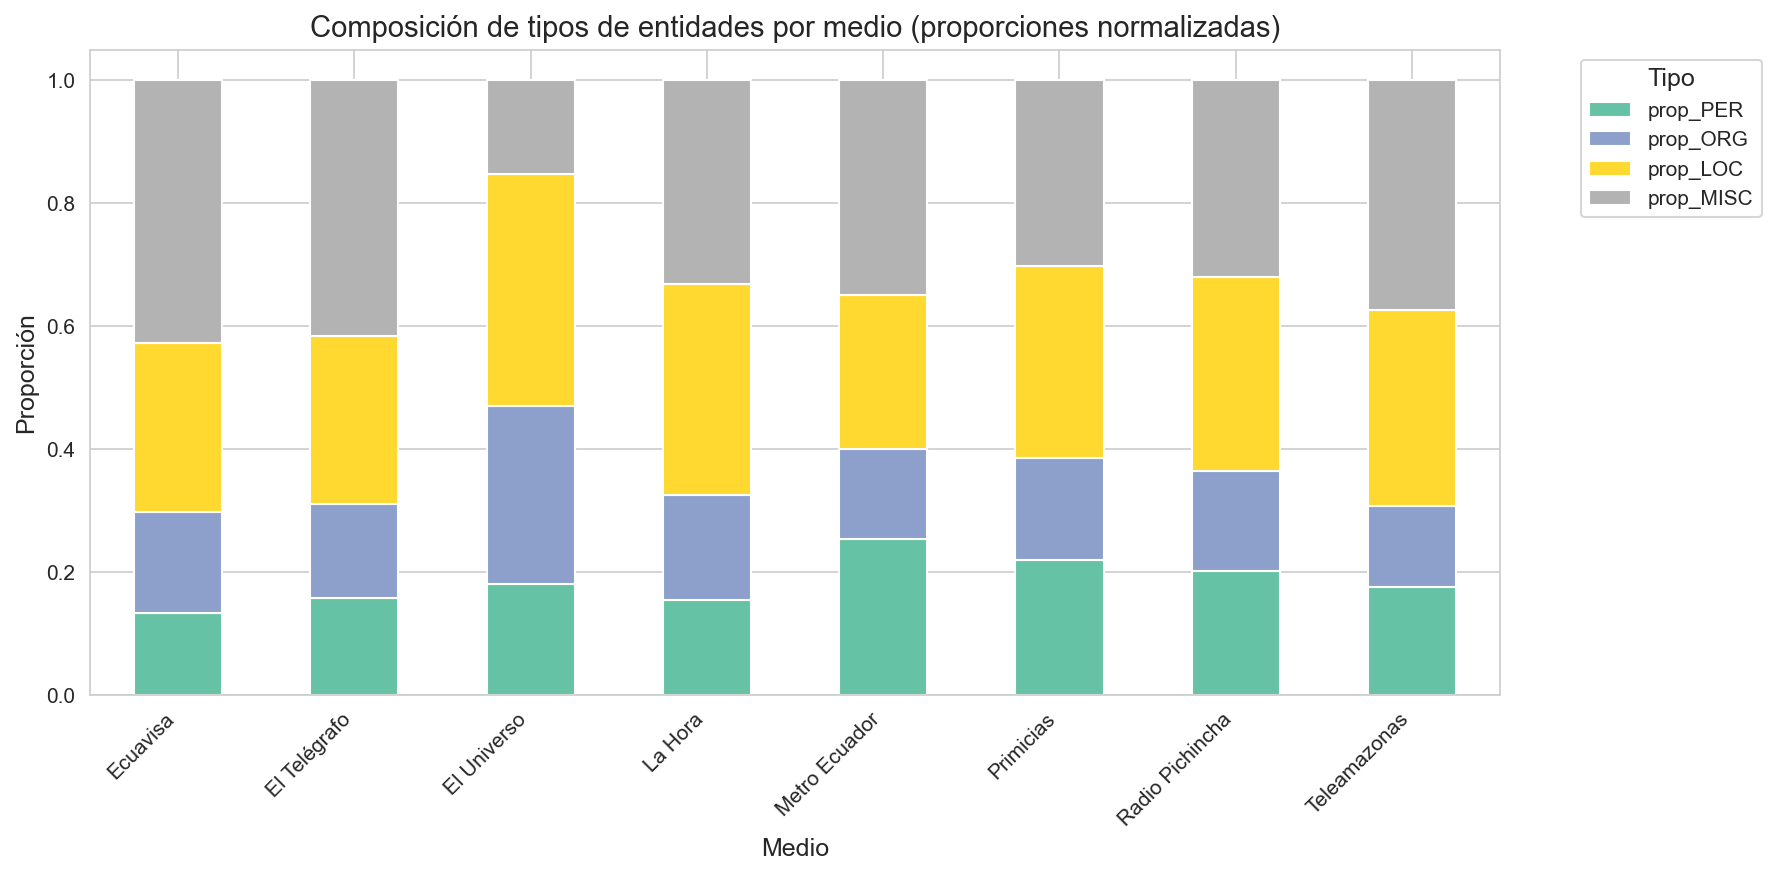

,medio,seccion,mean,std,count
0,Ecuavisa,General,0.188,0.030292,1749
1,El Telégrafo,General,0.194,0.053043,69
2,El Universo,Economía,0.151,0.063566,137
3,El Universo,General,0.160,0.057743,4
4,El Universo,Nacionales,0.170,0.079065,139
5,El Universo,Política,0.166,0.064935,228
6,El Universo,Sucesos/Seguridad,0.170,0.066740,66
7,La Hora,General,0.184,0.036916,1076
8,Metro Ecuador,Economía,0.139,0.044064,62
9,Metro Ecuador,Entretenimiento,0.169,0.050741,420


,prop_PER,prop_ORG,prop_LOC,prop_MISC
medio,,,,
Ecuavisa,0.0252,0.0308,0.0517,0.0805
El Telégrafo,0.0306,0.0297,0.0531,0.0807
El Universo,0.0295,0.0475,0.0620,0.0249
La Hora,0.0284,0.0315,0.0632,0.0609
Metro Ecuador,0.0454,0.0264,0.0447,0.0627
Primicias,0.0411,0.0310,0.0585,0.0565
Radio Pichincha,0.0354,0.0283,0.0552,0.0561
Teleamazonas,0.0335,0.0248,0.0608,0.0711


In [ ]:
# Usaremos el modelo spaCy para NER (ya cargado como 'nlp')
def extraer_entidades(doc):
    """Devuelve un diccionario con el conteo de entidades por tipo."""
    tipos = ['PER', 'ORG', 'LOC', 'MISC']
    conteo = {t:0 for t in tipos}
    for ent in doc.ents:
        if ent.label_ in tipos:
            conteo[ent.label_] += 1
    total_ent = sum(conteo.values())
    return conteo, total_ent

print("Aplicando NER al corpus (puede tomar varios minutos)...")
# Procesar por lotes
docs = list(nlp.pipe(df_total['cuerpo'].astype(str), batch_size=30, n_process=1))
ent_data = []
for doc in docs:
    cnt, total = extraer_entidades(doc)
    tokens = len([t for t in doc if not t.is_punct and not t.is_stop])
    ent_data.append({
        'PER': cnt['PER'], 'ORG': cnt['ORG'], 'LOC': cnt['LOC'], 'MISC': cnt['MISC'],
        'total_ent': total,
        'tokens_signif': tokens if tokens>0 else 1  # evitar división por cero
    })

df_ent = pd.DataFrame(ent_data)
df_ent['medio'] = df_total['medio'].values
df_ent['seccion'] = df_total['seccion'].values
# Proporción normalizada (entidades totales / tokens significativos)
df_ent['prop_total'] = df_ent['total_ent'] / df_ent['tokens_signif']
# Proporciones por tipo
for tipo in ['PER', 'ORG', 'LOC', 'MISC']:
    df_ent[f'prop_{tipo}'] = df_ent[tipo] / df_ent['tokens_signif']

# Heatmap: medio vs tipo de entidad (proporción media)
heatmap_data = df_ent.groupby('medio')[['prop_PER', 'prop_ORG', 'prop_LOC', 'prop_MISC']].mean()

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('Proporción media de entidades por tipo y medio')
plt.xlabel('Tipo de entidad')
plt.ylabel('Medio')
plt.tight_layout()
plt.show()

# Gráfico de barras apiladas normalizadas por medio
props_por_medio = df_ent.groupby('medio')[['prop_PER', 'prop_ORG', 'prop_LOC', 'prop_MISC']].mean()
props_por_medio = props_por_medio.div(props_por_medio.sum(axis=1), axis=0)  # normalizar a 100%
ax = props_por_medio.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title('Composición de tipos de entidades por medio (proporciones normalizadas)')
plt.xlabel('Medio')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# Tabla resumen de proporción total por medio y sección
resumen_total = df_ent.groupby(['medio', 'seccion'])['prop_total'].agg(['mean', 'std', 'count']).reset_index()
display(resumen_total.style.set_caption("Proporción total de entidades por medio y sección").format({'mean':'{:.3f}'}))
# Tabla detallada por tipo
resumen_tipo = df_ent.groupby('medio')[['prop_PER', 'prop_ORG', 'prop_LOC', 'prop_MISC']].mean()
display(resumen_tipo.style.set_caption("Proporción media por tipo de entidad y medio").format('{:.4f}'))